In [31]:
import os
os.makedirs('../visualisations', exist_ok=True)
os.makedirs('../data', exist_ok=True)

# Save cleaned dataset
df_clean.to_csv('../data/df_clean.csv', index=False)

# Re-save your figures as PNGs for HTML embedding
fig.savefig('../visualisations/heatmap.png', dpi=300, bbox_inches='tight')

PermissionError: [WinError 5] Access is denied: '../visualisations'

In [1]:
!pip install pandas matplotlib seaborn lxml

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ----------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
%pip install nba_api

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.5.1-cp314-cp314-win_amd64.whl.metadata (46 kB)
  Using cached idna-3.19-py3-none-any.whl.metadata (9.2 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached charset_normalizer-3.5.1-cp314-cp314-win_amd64.whl (204 kB)
Using cached idna-3.19-py3-none-any.whl (68 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)

   ---------------------------------------- 0/6 [urllib3]
   ------ --------------------------------- 1/6 [idna]
   ------------- -------------------------- 2/6 [charset_normalizer]
   -------------------------- ------------- 4/6 [requests]
   --------------------------------- ------ 5/6 [nba_api]
   --------------------------------- ------ 5/6 [nba_api]
   -------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from nba_api.stats.endpoints import leaguedashplayerstats

In [10]:
sns.set_theme(style="whitegrid")

In [5]:
print("Fetching data from NBA API...")

# Fetches player statistics for the 2023-24 season via NBA API
api_call = leaguedashplayerstats.LeagueDashPlayerStats(
    season='2023-24',
    season_type_all_star='Regular Season'
)

Fetching data from NBA API...


In [ ]:
# Converts API response directly to a Pandas DataFrame
df_raw = api_call.get_data_frames()[0]
print(f"Successfully fetched raw dataset: {df_raw.shape[0]} players.")

Successfully fetched raw dataset: 572 players.


In [ ]:
# Selects relevant metrics for MVP analysis
cols_to_keep = [
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN', 
    'PTS', 'REB', 'AST', 'STL', 'BLK', 'FG_PCT', 'PLUS_MINUS'
]
df_clean = df_raw[cols_to_keep].copy()

In [ ]:
# Filters for qualified players (at least 65 games played) to align with NBA minimum guidelines
df_clean = df_clean[df_clean['GP'] >= 65].reset_index(drop=True)

In [ ]:
# Features Engineering: Calculates per-game statistics
df_clean['PTS_PG'] = round(df_clean['PTS'] / df_clean['GP'], 1)
df_clean['REB_PG'] = round(df_clean['REB'] / df_clean['GP'], 1)
df_clean['AST_PG'] = round(df_clean['AST'] / df_clean['GP'], 1)

In [12]:
df_clean.fillna(0, inplace=True)

,PLAYER_NAME,TEAM_ABBREVIATION,GP,MIN,PTS,REB,AST,STL,BLK,FG_PCT,PLUS_MINUS,PTS_PG,REB_PG,AST_PG
0,Aaron Gordon,DEN,73,2296.810000,1013,471,259,56,45,0.556,423,13.9,6.5,3.5
1,Aaron Holiday,HOU,78,1269.296667,514,123,140,42,6,0.446,85,6.6,1.6,1.8
2,Aaron Nesmith,IND,72,1994.655000,877,275,108,65,49,0.496,161,12.2,3.8,1.5
3,Aaron Wiggins,OKC,78,1227.938333,542,186,86,56,19,0.562,94,6.9,2.4,1.1
4,Al Horford,BOS,65,1739.796667,562,413,168,38,62,0.511,421,8.6,6.4,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,Tyrese Maxey,PHI,70,2625.806667,1816,258,433,69,33,0.450,303,25.9,3.7,6.2
180,Tyus Jones,WAS,66,1932.666667,790,179,485,71,18,0.489,-497,12.0,2.7,7.3
181,Victor Wembanyama,SAS,71,2106.235000,1522,755,274,88,254,0.465,-143,21.4,10.6,3.9
182,Zach Collins,SAS,69,1525.728333,776,370,194,34,52,0.484,-393,11.2,5.4,2.8


In [13]:
print(f"Cleaned dataset shape after filtering: {df_clean.shape}")
print(df_clean[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'PTS_PG', 'PLUS_MINUS']].head())

Cleaned dataset shape after filtering: (184, 14)
     PLAYER_NAME TEAM_ABBREVIATION  GP  PTS_PG  PLUS_MINUS
0   Aaron Gordon               DEN  73    13.9         423
1  Aaron Holiday               HOU  78     6.6          85
2  Aaron Nesmith               IND  72    12.2         161
3  Aaron Wiggins               OKC  78     6.9          94
4     Al Horford               BOS  65     8.6         421


findfont: Failed to find font weight medium for Arial, now using 400.


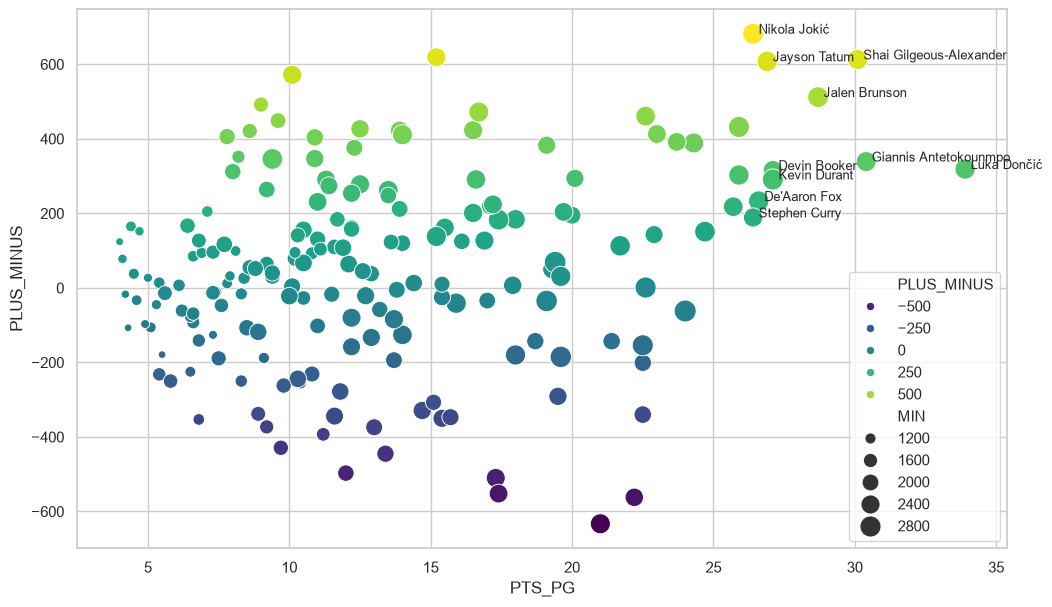

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = sns.scatterplot(
    data=df_clean,
    x='PTS_PG',
    y='PLUS_MINUS',
    size='MIN',
    hue='PLUS_MINUS',
    palette='viridis',
    sizes=(30, 250),
    ax=ax
)

# Annotate key top MVP candidates (scoring leaders with high +/-)
top_players = df_clean[df_clean['PTS_PG'] >= 26]
for idx, row in top_players.iterrows():
    ax.text(
        row['PTS_PG'] + 0.2, 
        row['PLUS_MINUS'], 
        row['PLAYER_NAME'], 
        fontsize=9,
        fontweight='medium'
    )

In [20]:
top_10_scorers = df_clean.sort_values(by='PTS_PG', ascending=False).head(10)

C:\Users\rames\AppData\Local\Temp\ipykernel_4936\3483148755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


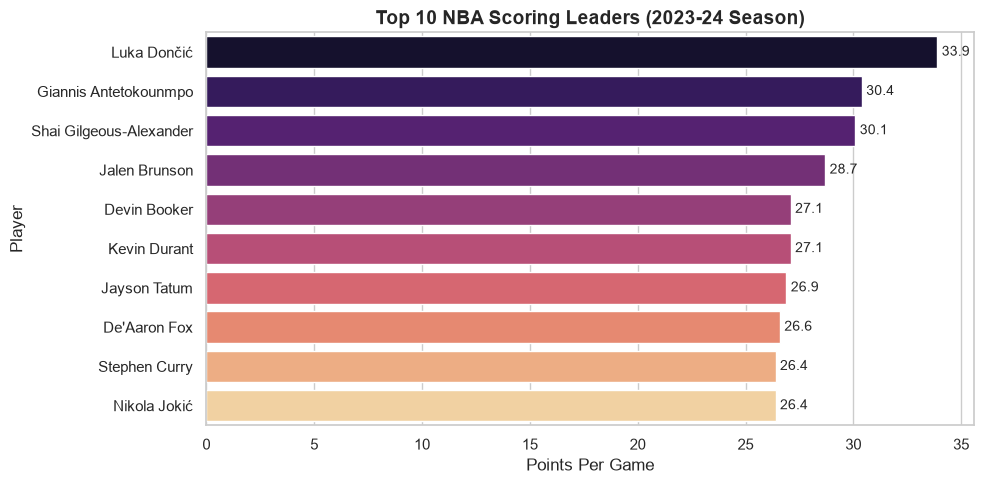

In [ ]:
plt.figure(figsize=(10, 5))
barplot = sns.barplot(
    data=top_10_scorers,
    x='PTS_PG',
    y='PLAYER_NAME',
    palette='magma'
)

plt.title('Top 10 NBA Scoring Leaders (2023-24 Season)', fontsize=14, fontweight='bold')
plt.xlabel('Points Per Game', fontsize=12)
plt.ylabel('Player', fontsize=12)

# Adds numeric value labels on each bar
for index, value in enumerate(top_10_scorers['PTS_PG']):
    plt.text(value + 0.2, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()


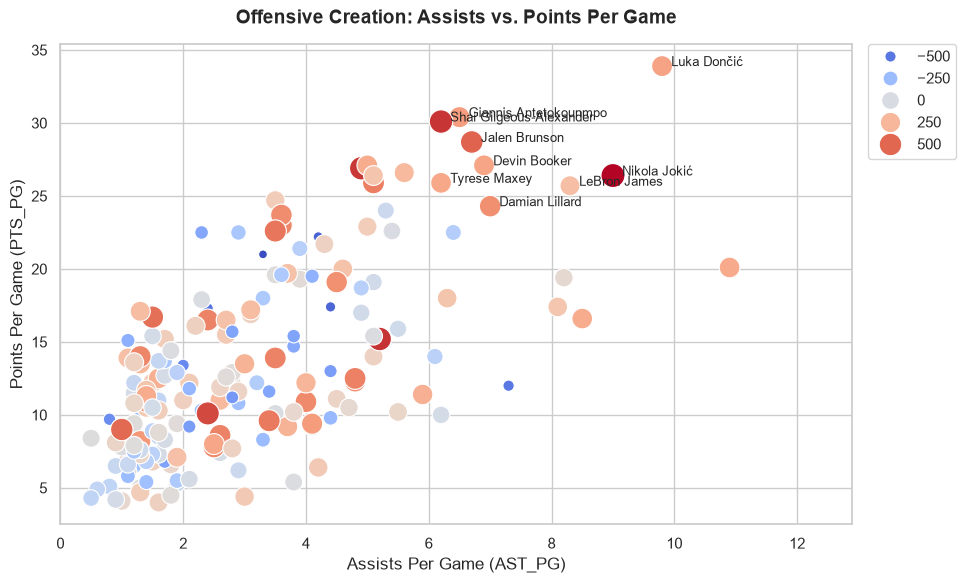

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=df_clean,
    x='AST_PG',
    y='PTS_PG',
    size='PLUS_MINUS',
    hue='PLUS_MINUS',
    palette='coolwarm',
    sizes=(40, 300),
    ax=ax
)

# Labels top playmakers/scorers
top_creators = df_clean[(df_clean['PTS_PG'] >= 24) & (df_clean['AST_PG'] >= 6)]
for idx, row in top_creators.iterrows():
    ax.text(row['AST_PG'] + 0.15, row['PTS_PG'], row['PLAYER_NAME'], fontsize=9)

ax.set_xlim(df_clean['AST_PG'].min() - 0.5, df_clean['AST_PG'].max() + 2)
plt.title('Offensive Creation: Assists vs. Points Per Game', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Assists Per Game (AST_PG)', fontsize=12)
plt.ylabel('Points Per Game (PTS_PG)', fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.subplots_adjust(left=0.08, right=0.80, top=0.90, bottom=0.10)
plt.show()